In [13]:
import torch, random
from statistics import mean
from cebmf_torch import cEBMF
import matplotlib.pyplot as plt
# ---- config
NUM_RUNS   = 20
N, P       = 50, 40
NOISE_STD  =  .1
MAXIT      = 50
TOL        = 1e-9   # numerical tolerance for strictness

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

def is_strictly_increasing(xs, tol=0.0001):
    # xs[t+1] > xs[t] + tol  for all t
    return all(xs[t+1] > xs[t] - tol for t in range(len(xs)-1))

def is_strictly_decreasing(xs, tol=0.001):
    # xs[t+1] < xs[t] - tol  for all t
    return all(xs[t+1] < xs[t] + tol for t in range(len(xs)-1))

def one_run(seed):
    # reproducibility
    random.seed(seed)
    torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
    u = torch.rand(N, device=device)
    v = torch.rand(P, device=device)
    Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

    model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp") 
    model.fit(maxit=MAXIT)

    loss_hist = model.obj                       # your stored objective = negative ELBO
    return(loss_hist)
 


results=[]

for i in range(NUM_RUNS):
    results.append( one_run(i))
 

In [14]:
import matplotlib.pyplot as plt

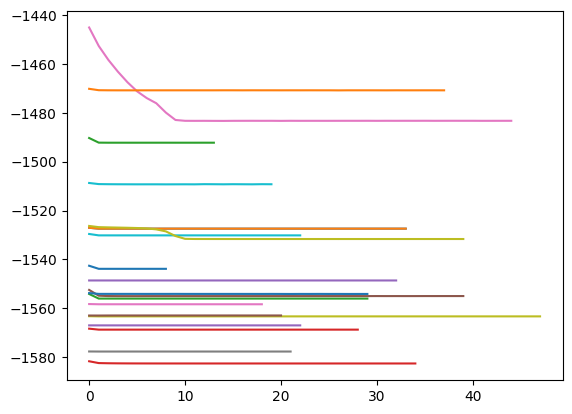

In [15]:
plt.plot(results[0])
for i in range(NUM_RUNS):
    plt.plot(results[i])

In [16]:
h=0

for i in range(NUM_RUNS):
    if (is_strictly_decreasing(results[i], tol=0.1))== False:
        h=h+1
print(h)

0


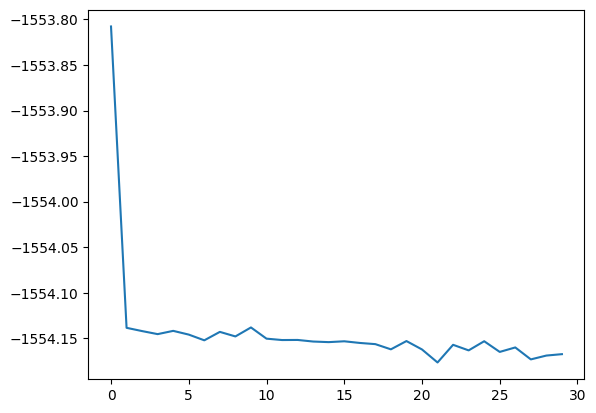

In [17]:
plt.plot(results[9])

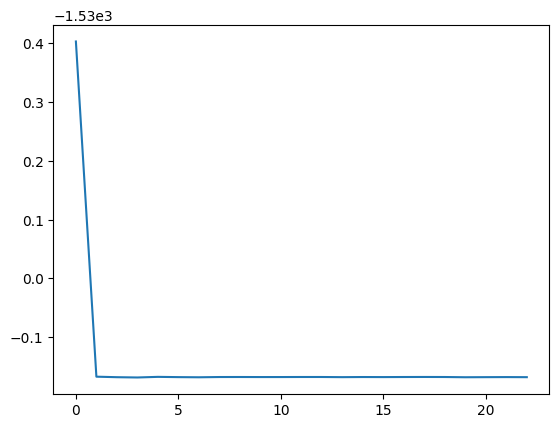

In [24]:
plt.plot(results[8])

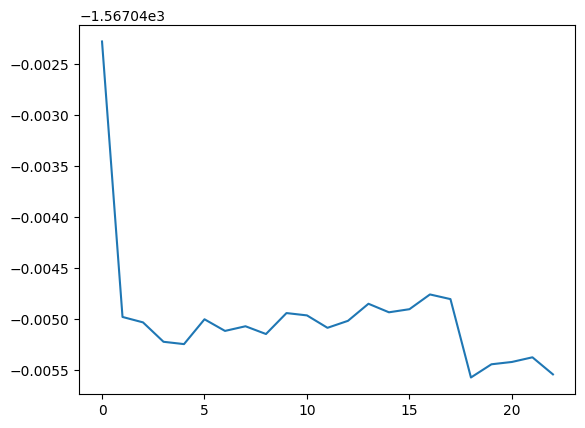

In [7]:
plt.plot(results[3])

In [8]:
seed=1
random.seed(seed)
torch.manual_seed(seed)

    # rank-1 signal + Gaussian noise
u = torch.rand(N, device=device)
v = torch.rand(P, device=device)
Y = torch.outer(u, v) + NOISE_STD * torch.randn(N, P, device=device)

model = cEBMF(data=Y, K=5, prior_F="exp",
                 prior_L="exp") 
model.fit(maxit=50)

CEBMFResult(L=tensor([[0.0405],
        [0.1587],
        [0.1584],
        [0.1144],
        [0.4111],
        [0.0306],
        [0.3362],
        [0.4939],
        [0.4221],
        [0.3772],
        [0.3595],
        [0.2416],
        [0.5079],
        [0.2966],
        [0.0823],
        [0.1081],
        [0.4709],
        [0.1350],
        [0.3479],
        [0.4883],
        [0.6502],
        [0.7160],
        [0.6180],
        [0.6033],
        [0.6162],
        [0.1104],
        [0.1040],
        [0.7112],
        [0.5625],
        [0.3378],
        [0.2693],
        [0.3045],
        [0.5660],
        [0.6457],
        [0.6717],
        [0.1087],
        [0.6826],
        [0.2361],
        [0.3030],
        [0.1995],
        [0.1662],
        [0.1604],
        [0.2209],
        [0.2931],
        [0.2434],
        [0.2009],
        [0.5568],
        [0.2226],
        [0.2916],
        [0.2128]], dtype=torch.float32), F=tensor([[0.9726],
        [0.3684],
        [0.5641],
       

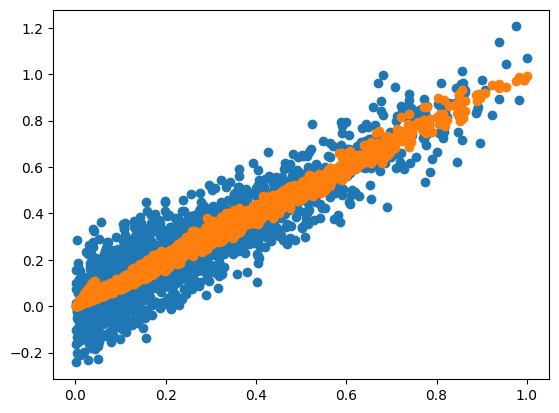

In [25]:
model._update_fitted_value()
plt.scatter(model.Y_fit, Y)
plt.scatter(model.Y_fit, torch.outer(u, v) )

In [26]:
model.obj

[-1554.1770248413086,
 -1556.0671615600586,
 -1556.0684432983398,
 -1556.0686798095703,
 -1556.069190979004,
 -1556.0692138671875,
 -1556.0694046020508,
 -1556.068946838379,
 -1556.069107055664,
 -1556.068862915039,
 -1556.069221496582,
 -1556.0690689086914,
 -1556.0690460205078,
 -1556.0689544677734,
 -1556.0691452026367,
 -1556.0692672729492,
 -1556.0691680908203,
 -1556.0690689086914,
 -1556.0689392089844,
 -1556.069351196289,
 -1556.0690841674805,
 -1556.0691299438477,
 -1556.0690994262695,
 -1556.0692443847656,
 -1556.0692901611328,
 -1556.069091796875,
 -1556.069107055664,
 -1556.0690841674805,
 -1556.0692291259766,
 -1556.068962097168]